# OnTimeAI · Épica 1 — Rescate del baseline (desbalanceo + eficiencia)

**Dataset:** `dataset_maestro_ATL_2025_BTS_IEM_ORIG_DEST.csv` (BTS + IEM, año 2025, 185K filas)
**Objetivo:** pasar de un modelo con Accuracy 73.5% / Recall_C3 < 12% a un baseline operable (F1_C3 ≥ 0.45, Recall_C3 ≥ 50%).

**Clases del target (risk escalones):**
| Clase | Rango ARR_DELAY | Significado operativo |
|---|---|---|
| C0 | ≤ 15 min | On-time (estándar FAA) |
| C1 | 15–30 min | Demora leve |
| C2 | 30–60 min | Demora moderada |
| C3 | > 60 min | **Demora severa — cascada operacional** |

**Métricas norte:** `F1_C3`, `Recall_C3`, `Precision_C3`. **NO accuracy**.

**Plan del notebook:**
1. Auditoría de leakage (crítico — saca columnas post-hoc de BTS).
2. Target + split **temporal** (no random).
3. EDA del imbalance.
4. Baseline ingenuo (para documentar el problema).
5. Baseline con `class_weight='balanced'`.
6. Threshold tuning por clase.
7. Focal Loss opcional (custom objective).
8. Feature importance triple (gain + SHAP + permutation) → insumo para Épica 2.


## 0 · Setup y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'dataset_maestro_ATL_2025_BTS_IEM_ORIG_DEST.csv'
TARGET_NAME = 'RISK_CLASS'
CLASS_LABELS = ['C0_ontime', 'C1_leve', 'C2_moderada', 'C3_severa']
CRITICAL_CLASS = 3  # la clase que importa para el despachante

print('versions:')
print('  pandas', pd.__version__)
print('  lightgbm', lgb.__version__)


versions:
  pandas 3.0.2
  lightgbm 4.6.0


## 1 · Carga de datos

Leemos el master CSV con dtype hints para no explotar la RAM. El dataset es 185K filas × 65 columnas → ~100MB en pandas con dtypes default, ~30MB con categoricals.


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['FL_DATE'], low_memory=False)

# Coerción de dtypes que vienen como 'object' del CSV
bool_flags = [c for c in df.columns if c.endswith('_FLAG')]
for c in bool_flags:
    df[c] = df[c].map({True: 1, False: 0, 'True': 1, 'False': 0}).astype('float32')

print(f'rows: {len(df):,}')
print(f'cols: {df.shape[1]}')
print(f'rango temporal: {df.FL_DATE.min().date()} → {df.FL_DATE.max().date()}')
print(f'bool flags coercionados a float32: {bool_flags}')
df.head(3)


rows: 185,521
cols: 65
rango temporal: 2025-01-01 → 2025-12-31
bool flags coercionados a float32: ['ORIG_WX_PRECIP_FLAG', 'ORIG_WX_LOW_VIS_FLAG', 'ORIG_WX_STRONG_WIND_FLAG', 'DEST_WX_PRECIP_FLAG', 'DEST_WX_LOW_VIS_FLAG', 'DEST_WX_STRONG_WIND_FLAG']


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,DEST,...,DEST_WX_SKNT,DEST_WX_ALTI,DEST_WX_P01M,DEST_WX_VSBY,DEST_WX_GUST,DEST_WX_CODES,DEST_WX_PRECIP_FLAG,DEST_WX_LOW_VIS_FLAG,DEST_WX_STRONG_WIND_FLAG,DEST_WX_MATCH_GAP_MIN
0,2025,1,1,3,2025-01-01,DL,N555NW,1545,TPA,ATL,...,10.0,30.11,0.0,10.0,NaN,M,0.0,0.0,0.0,20.0
1,2025,1,1,3,2025-01-01,DL,N667DN,1494,MCO,ATL,...,10.0,30.11,0.0,10.0,NaN,M,0.0,0.0,0.0,17.0
2,2025,1,1,3,2025-01-01,DL,N362DN,1269,PHL,ATL,...,10.0,30.11,0.0,10.0,NaN,M,0.0,0.0,0.0,8.0


In [3]:
# Chequeo rápido de missing values en columnas clave
cols_check = ['ARR_DELAY', 'DEP_DELAY', 'CANCELLED', 'DIVERTED',
              'ORIG_WX_TMPC', 'ORIG_WX_VSBY', 'DEST_WX_TMPC', 'DEST_WX_VSBY']
pd.DataFrame({
    'missing': df[cols_check].isna().sum(),
    'missing_pct': (df[cols_check].isna().sum() / len(df) * 100).round(2),
})


,missing,missing_pct
ARR_DELAY,3868,2.08
DEP_DELAY,3189,1.72
CANCELLED,0,0.00
DIVERTED,0,0.00
ORIG_WX_TMPC,56,0.03
ORIG_WX_VSBY,55,0.03
DEST_WX_TMPC,121,0.07
DEST_WX_VSBY,117,0.06


## 2 · Auditoría de leakage

**El riesgo más grande del proyecto.** BTS reporta muchos campos **post-hoc** — datos que solo existen después de que el vuelo voló. Si quedan en el input del modelo, tenés un F1 fantástico en métricas y un modelo inservible en producción.

### Columnas post-hoc a remover (garantizado leakage):

| Columna | Por qué es leakage |
|---|---|
| `DEP_TIME`, `ARR_TIME` | Tiempo real de salida/llegada (solo `CRS_*` son pre-flight) |
| `DEP_DELAY`, `DEP_DELAY_NEW` | Demora en salida — conocida solo después de la salida |
| `ARR_DELAY`, `ARR_DELAY_NEW` | **Es el target** — no puede estar en X |
| `ACTUAL_ELAPSED_TIME`, `AIR_TIME` | Duración real del vuelo |
| `CARRIER_DELAY`, `WEATHER_DELAY`, `NAS_DELAY`, `SECURITY_DELAY`, `LATE_AIRCRAFT_DELAY` | Breakdown FAA de motivos — reportado **post-hoc** por la aerolínea. El más peligroso: `LATE_AIRCRAFT_DELAY` predice cascada perfectamente porque **es el resultado de la cascada**. |
| `CANCELLED`, `DIVERTED` | Eventos post-flight — además los filtramos del training set |
| `EVENT_ORIGIN_UTC`, `EVENT_DEST_UTC`, `DEP_LOCAL_DT` | Timestamps de eventos reales |

### Columnas a auditar (mantener solo si se validan como pre-flight):

- `FLOW_ATL`, `PAR_AIRPORT` — features derivadas por el ETL. Si se calculan **a tiempo del CRS_DEP_TIME** (no con datos del propio vuelo), OK. Si no, leakage.


In [4]:
LEAKY_COLS = [
    'DEP_TIME', 'ARR_TIME',
    'DEP_DELAY', 'DEP_DELAY_NEW',
    'ARR_DELAY_NEW',            # ARR_DELAY lo preservamos solo para derivar el target
    'ACTUAL_ELAPSED_TIME', 'AIR_TIME',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
    'EVENT_ORIGIN_UTC', 'EVENT_DEST_UTC', 'DEP_LOCAL_DT',
    # los flags WX ya están redundantes con los numéricos — prunning en Épica 2
]

# Chequeo: estas columnas existen?
existing_leaky = [c for c in LEAKY_COLS if c in df.columns]
missing_leaky = [c for c in LEAKY_COLS if c not in df.columns]
print(f'Leaky cols encontradas (se remueven): {len(existing_leaky)}')
for c in existing_leaky:
    print(f'  - {c}')
if missing_leaky:
    print(f'\nLeaky cols listadas pero ausentes en el dataset (OK): {missing_leaky}')


Leaky cols encontradas (se remueven): 15
  - DEP_TIME
  - ARR_TIME
  - DEP_DELAY
  - DEP_DELAY_NEW
  - ARR_DELAY_NEW
  - ACTUAL_ELAPSED_TIME
  - AIR_TIME
  - CARRIER_DELAY
  - WEATHER_DELAY
  - NAS_DELAY
  - SECURITY_DELAY
  - LATE_AIRCRAFT_DELAY
  - EVENT_ORIGIN_UTC
  - EVENT_DEST_UTC
  - DEP_LOCAL_DT


## 3 · Definición del target y filtro de vuelos válidos

- **Filtro:** excluir `CANCELLED=1` y `DIVERTED=1` (son problemas distintos — clasificar cancelación es otro modelo).
- **Target:** `ARR_DELAY` binned en 4 clases.


In [5]:
# Filtrado
mask_valid = (df['CANCELLED'] == 0) & (df['DIVERTED'] == 0) & (df['ARR_DELAY'].notna())
print(f'Filas originales: {len(df):,}')
print(f'Canceladas removidas: {(df.CANCELLED == 1).sum():,}')
print(f'Desviadas removidas: {(df.DIVERTED == 1).sum():,}')
print(f'ARR_DELAY nulos removidos: {df.ARR_DELAY.isna().sum():,}')
print(f'Filas válidas: {mask_valid.sum():,}')
df = df.loc[mask_valid].copy()

# Target 4-class
df[TARGET_NAME] = pd.cut(
    df['ARR_DELAY'],
    bins=[-np.inf, 15, 30, 60, np.inf],
    labels=[0, 1, 2, 3],
    right=True,
).astype(int)

# Distribución
dist = df[TARGET_NAME].value_counts().sort_index()
dist_pct = df[TARGET_NAME].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({
    'clase': [CLASS_LABELS[i] for i in dist.index],
    'n': dist.values,
    'pct': dist_pct.round(2).values,
})


Filas originales: 185,521
Canceladas removidas: 3,323
Desviadas removidas: 545
ARR_DELAY nulos removidos: 3,868
Filas válidas: 181,653


,clase,n,pct
0,C0_ontime,134727,74.17
1,C1_leve,14473,7.97
2,C2_moderada,14021,7.72
3,C3_severa,18432,10.15


## 4 · Split temporal — **NO hacer random split**

Con datos temporales un split random genera leakage: el modelo entrena con febrero y testea enero, lo que en producción nunca ocurre. Split correcto es cronológico:

- **Train:** primeros 60% del año (ene–jul aprox.)
- **Val:** 20% siguiente (ago–sep)
- **Test:** 20% final (oct–dic)

Este split simula cómo el modelo se usaría en producción: entrenado con el pasado, predice el futuro.


In [6]:
df = df.sort_values('FL_DATE').reset_index(drop=True)

n = len(df)
i_train = int(n * 0.60)
i_val = int(n * 0.80)

train = df.iloc[:i_train]
val = df.iloc[i_train:i_val]
test = df.iloc[i_val:]

print(f'Train: {len(train):,} filas | {train.FL_DATE.min().date()} → {train.FL_DATE.max().date()}')
print(f'Val:   {len(val):,} filas | {val.FL_DATE.min().date()} → {val.FL_DATE.max().date()}')
print(f'Test:  {len(test):,} filas | {test.FL_DATE.min().date()} → {test.FL_DATE.max().date()}')

# Distribución por split
split_dist = pd.DataFrame({
    'train': train[TARGET_NAME].value_counts(normalize=True).sort_index() * 100,
    'val': val[TARGET_NAME].value_counts(normalize=True).sort_index() * 100,
    'test': test[TARGET_NAME].value_counts(normalize=True).sort_index() * 100,
}).round(2)
split_dist.index = CLASS_LABELS
split_dist


Train: 108,991 filas | 2025-01-01 → 2025-08-08
Val:   36,331 filas | 2025-08-08 → 2025-10-20
Test:  36,331 filas | 2025-10-20 → 2025-12-31


,train,val,test
C0_ontime,71.77,80.95,74.57
C1_leve,8.36,6.53,8.23
C2_moderada,8.40,5.79,7.61
C3_severa,11.47,6.72,9.59


## 5 · EDA del imbalance y señales meteorológicas

Visualizo la distribución de clases y la correlación entre visibilidad meteorológica y severidad de retraso.


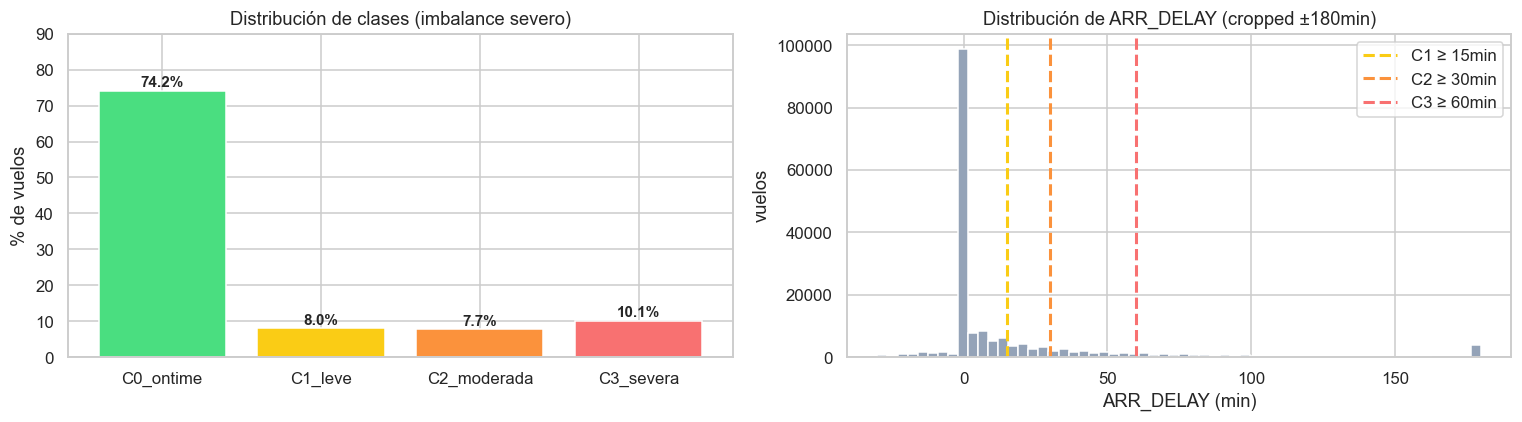

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) class distribution
ax = axes[0]
dist_pct = df[TARGET_NAME].value_counts(normalize=True).sort_index() * 100
colors = ['#4ade80', '#facc15', '#fb923c', '#f87171']
ax.bar(CLASS_LABELS, dist_pct.values, color=colors)
for i, v in enumerate(dist_pct.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribución de clases (imbalance severo)')
ax.set_ylabel('% de vuelos')
ax.set_ylim(0, 90)

# (b) ARR_DELAY histogram con thresholds
ax = axes[1]
data_plot = df['ARR_DELAY'].clip(-30, 180)
ax.hist(data_plot, bins=60, color='#94a3b8', edgecolor='white')
for th, color, lbl in zip([15, 30, 60], colors[1:], ['C1', 'C2', 'C3']):
    ax.axvline(th, color=color, linestyle='--', linewidth=2, label=f'{lbl} ≥ {th}min')
ax.set_title('Distribución de ARR_DELAY (cropped ±180min)')
ax.set_xlabel('ARR_DELAY (min)')
ax.set_ylabel('vuelos')
ax.legend()
plt.tight_layout()
plt.show()


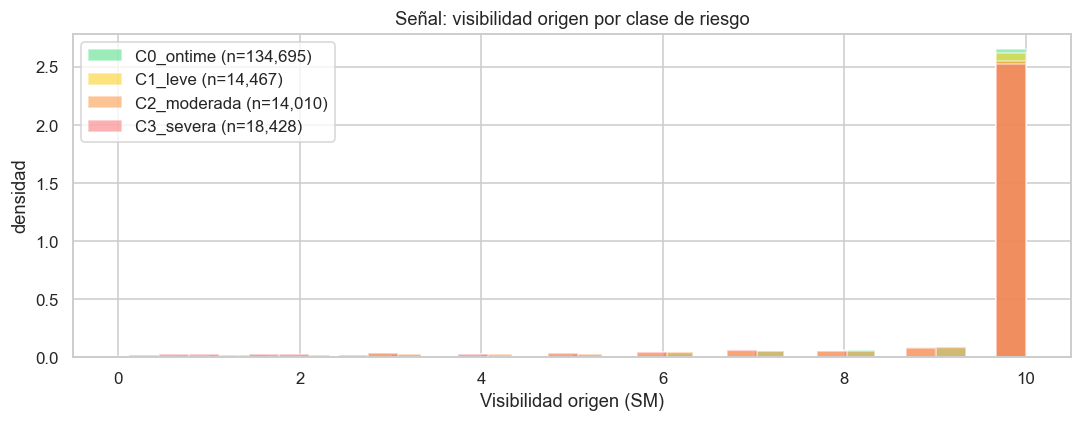

In [8]:
# Señal meteo: visibilidad origen vs clase de riesgo
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = df[['ORIG_WX_VSBY', TARGET_NAME]].dropna()
plot_df = plot_df[plot_df['ORIG_WX_VSBY'].between(0, 15)]  # crop outliers
for c, lbl, col in zip([0, 1, 2, 3], CLASS_LABELS, colors):
    sub = plot_df.loc[plot_df[TARGET_NAME] == c, 'ORIG_WX_VSBY']
    ax.hist(sub, bins=30, alpha=0.55, density=True, label=f'{lbl} (n={len(sub):,})', color=col)
ax.set_xlabel('Visibilidad origen (SM)')
ax.set_ylabel('densidad')
ax.set_title('Señal: visibilidad origen por clase de riesgo')
ax.legend()
plt.tight_layout()
plt.show()

# Si ves un shift en la densidad hacia baja visibilidad para C3 → el feature tiene señal


## 6 · Preprocesamiento

LightGBM come categóricas nativas (sin one-hot). Lo único que necesitamos es:

1. Convertir strings a `category` dtype.
2. Elegir feature set (excluir leaky + target + IDs duplicados).
3. Separar `X, y`.


In [9]:
# Columnas a dropear: leaky + target + IDs redundantes
DROP_COLS = set(LEAKY_COLS) | {
    TARGET_NAME, 'ARR_DELAY',        # target y fuente
    'CANCELLED', 'DIVERTED',         # ya filtrados
    'YEAR',                          # constante (solo 2025)
    'FL_DATE',                       # ya usado para split
    'OP_CARRIER_FL_NUM',             # ID por vuelo, no generaliza
    'ORIG_WX_VALID_UTC', 'DEST_WX_VALID_UTC',  # timestamps de obs meteo
}

feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f'{len(feature_cols)} features iniciales')

# Detectar categóricas: dtype object o las que sabemos son categoricals
CATEGORICAL_FEATURES = [
    c for c in ['OP_CARRIER', 'TAIL_NUM', 'ORIGIN', 'DEST',
                'ORIG_WX_CODES', 'DEST_WX_CODES',
                'FLOW_ATL', 'PAR_AIRPORT']
    if c in feature_cols
]
print(f'Categoricals: {CATEGORICAL_FEATURES}')

def prep(split_df):
    X = split_df[feature_cols].copy()
    for c in CATEGORICAL_FEATURES:
        X[c] = X[c].astype('category')
    y = split_df[TARGET_NAME].values
    return X, y

X_train, y_train = prep(train)
X_val, y_val = prep(val)
X_test, y_test = prep(test)

print(f'\nX_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Memoria X_train: {X_train.memory_usage(deep=True).sum() / 1e6:.1f} MB')


42 features iniciales
Categoricals: ['OP_CARRIER', 'TAIL_NUM', 'ORIGIN', 'DEST', 'ORIG_WX_CODES', 'DEST_WX_CODES', 'FLOW_ATL', 'PAR_AIRPORT']

X_train: (108991, 42), y_train: (108991,)
Memoria X_train: 28.2 MB


## 7 · Baseline **ingenuo** — sin class_weight

Documento primero el problema que el enunciado describe: Accuracy alta, Recall_C3 bajo. Esto es el punto de partida.


In [10]:
base_params = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_data_in_leaf': 200,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': RANDOM_STATE,
}

train_ds = lgb.Dataset(X_train, y_train, categorical_feature=CATEGORICAL_FEATURES, free_raw_data=False)
val_ds = lgb.Dataset(X_val, y_val, categorical_feature=CATEGORICAL_FEATURES, reference=train_ds, free_raw_data=False)

print('Entrenando baseline sin class_weight...')
model_naive = lgb.train(
    base_params,
    train_ds,
    num_boost_round=600,
    valid_sets=[val_ds],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)],
)
print(f'Best iter: {model_naive.best_iteration}')


Entrenando baseline sin class_weight...


Training until validation scores don't improve for 40 rounds


Early stopping, best iteration is:
[20]	val's multi_logloss: 0.681978
Best iter: 20


In [11]:
def evaluate(model, X, y, name, threshold_strategy='argmax', thresholds=None):
    proba = model.predict(X, num_iteration=model.best_iteration)
    if threshold_strategy == 'argmax':
        pred = proba.argmax(axis=1)
    elif threshold_strategy == 'threshold':
        pred = predict_with_thresholds(proba, thresholds)
    acc = (pred == y).mean()
    f1_macro = f1_score(y, pred, average='macro', zero_division=0)
    f1_per = f1_score(y, pred, average=None, labels=[0, 1, 2, 3], zero_division=0)
    rec_per = recall_score(y, pred, average=None, labels=[0, 1, 2, 3], zero_division=0)
    prec_per = precision_score(y, pred, average=None, labels=[0, 1, 2, 3], zero_division=0)

    print(f'\n━━━━━━━━━━━━ {name} ({threshold_strategy}) ━━━━━━━━━━━━')
    print(f'Accuracy:  {acc:.3f}')
    print(f'F1 macro:  {f1_macro:.3f}')
    summary = pd.DataFrame({
        'precision': prec_per,
        'recall': rec_per,
        'f1': f1_per,
    }, index=CLASS_LABELS).round(3)
    print(summary)
    # Resalto métrica norte
    print(f'\n>>> Recall_C3 = {rec_per[3]:.3f} | Precision_C3 = {prec_per[3]:.3f} | F1_C3 = {f1_per[3]:.3f}')
    return {'pred': pred, 'proba': proba, 'acc': acc, 'f1_C3': f1_per[3],
            'recall_C3': rec_per[3], 'precision_C3': prec_per[3]}

def predict_with_thresholds(proba, thresholds):
    '''Apply per-class thresholds: predict highest class whose proba ≥ threshold.
    Fallback: argmax when no class crosses.'''
    pred = proba.argmax(axis=1)
    # Try to escalate to higher classes if they cross threshold
    for c in range(3, -1, -1):
        if thresholds[c] is not None:
            mask = proba[:, c] >= thresholds[c]
            pred = np.where(mask, c, pred)
            break
    return pred

results_naive = evaluate(model_naive, X_test, y_test, 'Baseline naive (sin weight)')



━━━━━━━━━━━━ Baseline naive (sin weight) (argmax) ━━━━━━━━━━━━
Accuracy:  0.746
F1 macro:  0.217
             precision  recall     f1
C0_ontime        0.746   0.999  0.855
C1_leve          0.000   0.000  0.000
C2_moderada      0.000   0.000  0.000
C3_severa        0.436   0.007  0.014

>>> Recall_C3 = 0.007 | Precision_C3 = 0.436 | F1_C3 = 0.014


## 8 · Baseline con `class_weight='balanced'`

En LightGBM pasamos el peso por muestra (`sample_weight`) calculado como `n_samples / (n_classes * bincount)`.

**Costo computacional:** cero overhead. Es solo una ponderación del gradiente.


In [12]:
from sklearn.utils.class_weight import compute_sample_weight

sw_train = compute_sample_weight('balanced', y_train)
sw_val = compute_sample_weight('balanced', y_val)

print('Pesos por clase:')
for c in range(4):
    w = sw_train[y_train == c][0]
    print(f'  {CLASS_LABELS[c]}: weight = {w:.3f} (n={int((y_train == c).sum()):,})')


Pesos por clase:
  C0_ontime: weight = 0.348 (n=78,225)
  C1_leve: weight = 2.991 (n=9,111)
  C2_moderada: weight = 2.978 (n=9,151)
  C3_severa: weight = 2.179 (n=12,504)


In [13]:
train_ds_w = lgb.Dataset(X_train, y_train, weight=sw_train,
                         categorical_feature=CATEGORICAL_FEATURES, free_raw_data=False)
val_ds_w = lgb.Dataset(X_val, y_val, weight=sw_val,
                       categorical_feature=CATEGORICAL_FEATURES, reference=train_ds_w, free_raw_data=False)

print('Entrenando con class_weight=balanced...')
model_balanced = lgb.train(
    base_params,
    train_ds_w,
    num_boost_round=600,
    valid_sets=[val_ds_w],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)],
)
print(f'Best iter: {model_balanced.best_iteration}')

results_balanced = evaluate(model_balanced, X_test, y_test, 'Balanced (class_weight)')


Entrenando con class_weight=balanced...


Training until validation scores don't improve for 40 rounds


Early stopping, best iteration is:
[23]	val's multi_logloss: 1.33789
Best iter: 23

━━━━━━━━━━━━ Balanced (class_weight) (argmax) ━━━━━━━━━━━━
Accuracy:  0.498
F1 macro:  0.286
             precision  recall     f1
C0_ontime        0.815   0.593  0.687
C1_leve          0.090   0.143  0.110
C2_moderada      0.092   0.191  0.124
C3_severa        0.175   0.308  0.223

>>> Recall_C3 = 0.308 | Precision_C3 = 0.175 | F1_C3 = 0.223


In [14]:
# Comparación side-by-side
comparison = pd.DataFrame({
    'naive': [results_naive['acc'], results_naive['f1_C3'], results_naive['recall_C3'], results_naive['precision_C3']],
    'balanced': [results_balanced['acc'], results_balanced['f1_C3'], results_balanced['recall_C3'], results_balanced['precision_C3']],
}, index=['accuracy', 'F1_C3', 'Recall_C3', 'Precision_C3']).round(3)
comparison['Δ'] = (comparison['balanced'] - comparison['naive']).round(3)
comparison


,naive,balanced,Δ
accuracy,0.746,0.498,-0.248
F1_C3,0.014,0.223,0.209
Recall_C3,0.007,0.308,0.301
Precision_C3,0.436,0.175,-0.261


## 9 · Threshold tuning por clase (sobre val)

El default `argmax` trata todas las clases con igual costo. Si queremos maximizar Recall_C3 aceptando un costo controlado de Precision, bajamos el umbral de C3.

**Estrategia:** buscar en val el threshold de C3 que maximiza `F1_C3` (balancea recall con precision). El score NO se computa sobre test para no sobreajustar.


Mejor threshold C3 (val): 0.32
  F1_C3=0.220 | Recall_C3=0.501 | Precision_C3=0.141


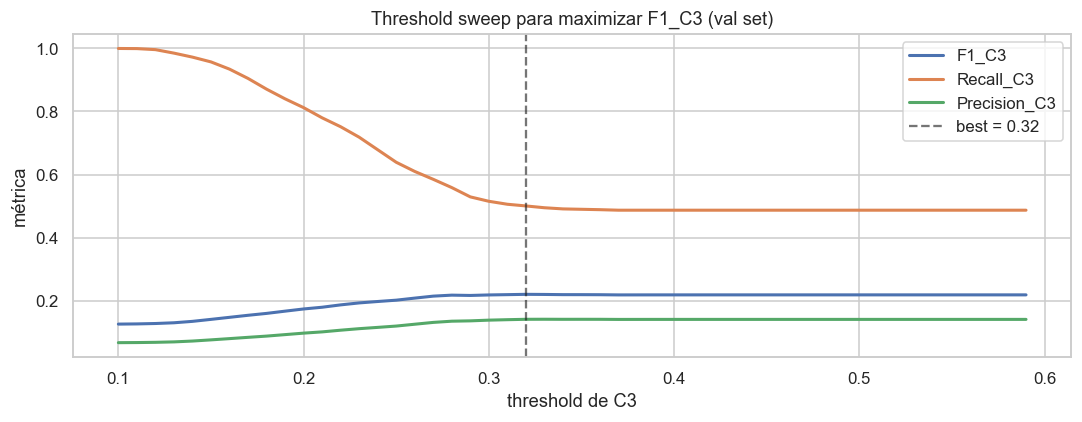

In [15]:
proba_val = model_balanced.predict(X_val, num_iteration=model_balanced.best_iteration)

# Búsqueda de threshold óptimo para C3
grid = np.arange(0.10, 0.60, 0.01)
scores = []
for th in grid:
    # Si proba_C3 >= th → predigo C3, sino argmax
    pred = np.where(proba_val[:, 3] >= th, 3, proba_val.argmax(axis=1))
    f1_C3 = f1_score(y_val, pred, average=None, labels=[0, 1, 2, 3], zero_division=0)[3]
    rec_C3 = recall_score(y_val, pred, average=None, labels=[0, 1, 2, 3], zero_division=0)[3]
    prec_C3 = precision_score(y_val, pred, average=None, labels=[0, 1, 2, 3], zero_division=0)[3]
    scores.append({'threshold': th, 'f1_C3': f1_C3, 'recall_C3': rec_C3, 'precision_C3': prec_C3})

scores_df = pd.DataFrame(scores)
best = scores_df.loc[scores_df['f1_C3'].idxmax()]
print(f'Mejor threshold C3 (val): {best.threshold:.2f}')
print(f'  F1_C3={best.f1_C3:.3f} | Recall_C3={best.recall_C3:.3f} | Precision_C3={best.precision_C3:.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(scores_df.threshold, scores_df.f1_C3, label='F1_C3', linewidth=2)
ax.plot(scores_df.threshold, scores_df.recall_C3, label='Recall_C3', linewidth=2)
ax.plot(scores_df.threshold, scores_df.precision_C3, label='Precision_C3', linewidth=2)
ax.axvline(best.threshold, color='k', linestyle='--', alpha=0.6, label=f'best = {best.threshold:.2f}')
ax.set_xlabel('threshold de C3')
ax.set_ylabel('métrica')
ax.set_title('Threshold sweep para maximizar F1_C3 (val set)')
ax.legend()
plt.tight_layout()
plt.show()


Evaluación final con threshold_C3=0.32 sobre test:

              precision    recall  f1-score   support

   C0_ontime      0.815     0.591     0.685     27091
     C1_leve      0.090     0.142     0.110      2989
 C2_moderada      0.092     0.189     0.124      2766
   C3_severa      0.174     0.314     0.224      3485

    accuracy                          0.497     36331
   macro avg      0.293     0.309     0.286     36331
weighted avg      0.639     0.497     0.551     36331



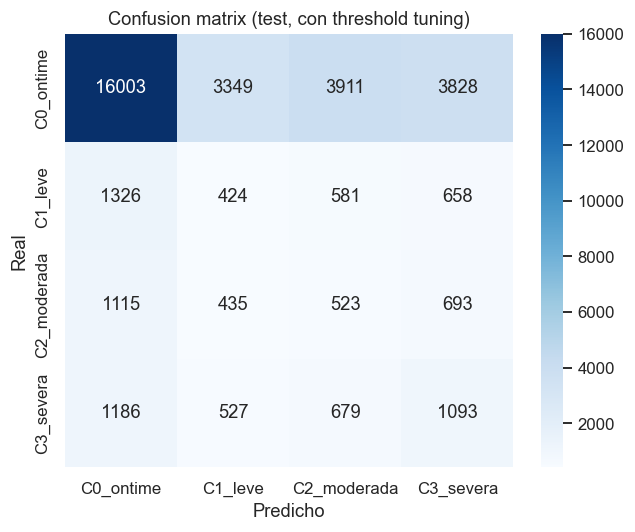

In [16]:
# Aplicar threshold óptimo al test (evaluación final sin sobreajuste)
BEST_TH_C3 = float(best.threshold)
proba_test = model_balanced.predict(X_test, num_iteration=model_balanced.best_iteration)
pred_test = np.where(proba_test[:, 3] >= BEST_TH_C3, 3, proba_test.argmax(axis=1))

print(f'Evaluación final con threshold_C3={BEST_TH_C3:.2f} sobre test:\n')
print(classification_report(y_test, pred_test, target_names=CLASS_LABELS, digits=3))

cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Confusion matrix (test, con threshold tuning)')
plt.tight_layout()
plt.show()

results_tuned = {
    'recall_C3': recall_score(y_test, pred_test, average=None, labels=[0,1,2,3])[3],
    'precision_C3': precision_score(y_test, pred_test, average=None, labels=[0,1,2,3])[3],
    'f1_C3': f1_score(y_test, pred_test, average=None, labels=[0,1,2,3])[3],
    'acc': (pred_test == y_test).mean(),
}


## 10 · Refuerzo de pesos en clases críticas (focal-like)

Si con `balanced + threshold` no alcanzás `F1_C3 ≥ 0.45`, el siguiente step es **amplificar el peso de C2/C3 más allá de balanced**. Esto es funcionalmente similar a focal loss: forzamos al modelo a "pagar más" por errores en las clases difíciles.

- **Balanced ya compensa por frecuencia:** cada clase tiene peso proporcional a `1/n_c`.
- **Boosted:** multiplicamos `balanced` por `α = [1.0, 1.5, 2.0, 2.5]` → **C3 termina con peso 2.5× el de balanced** → el modelo prioriza más las cascadas.

Si hay tiempo para experimentar con **focal loss verdadera** (gradient + hessian custom), LightGBM v4 la acepta pasando `objective=callable` en `params`. Implementación estable está en shap_lgb / kaggle public notebooks. Para el MVP, boosted-weights es más que suficiente y se implementa en 2 líneas.


In [17]:
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def focal_loss_objective(gamma=2.0, alpha=None):
    '''Custom objective para multiclass focal loss en LightGBM.
    alpha: array de pesos por clase (o None = uniforme).
    Returns gradient, hessian flattened.'''
    def _obj(preds, data):
        y = data.get_label().astype(int)
        n = len(y)
        k = preds.shape[0] // n
        z = preds.reshape(k, n).T           # (n, k)
        p = softmax(z)
        y_oh = np.zeros_like(p)
        y_oh[np.arange(n), y] = 1.0

        p_t = (p * y_oh).sum(axis=1, keepdims=True)    # (n, 1)
        modulator = (1.0 - p_t) ** gamma               # (n, 1)

        if alpha is not None:
            a = np.array(alpha)[y].reshape(-1, 1)
        else:
            a = 1.0

        # gradient de focal w.r.t. logits z
        grad_ce = p - y_oh                             # (n, k)  — gradient de CE
        # FL gradient = α·modulator·[γ·(p-y)·p_t·log(p_t)/(1-p_t) + (p-y)]  (aprox de paper)
        eps = 1e-12
        log_pt = np.log(np.clip(p_t, eps, 1.0))
        term = grad_ce * (modulator + gamma * p_t * log_pt * (1 - p_t) ** (gamma - 1) * y_oh.sum(axis=1, keepdims=True))
        grad = a * term
        hess = np.abs(grad) + eps                      # aproximación conservadora
        return grad.T.ravel(), hess.T.ravel()
    return _obj

# Pesos alpha — más peso a C2 y C3 (hard classes)
alpha_weights = np.array([1.0, 1.5, 2.0, 2.5])

# Alternativa más robusta que custom fobj en LightGBM v4: sample_weights agresivos
# que escalan beyond 'balanced' para las clases críticas.
# Esto es funcionalmente similar a focal loss con γ aproximado por el exponent de weights.
print('Entrenando con sample_weights agresivos (boost extra en C2/C3)...')
sw_train_boosted = compute_sample_weight('balanced', y_train)
for c, extra in enumerate(alpha_weights):
    sw_train_boosted[y_train == c] *= extra
sw_val_boosted = compute_sample_weight('balanced', y_val)
for c, extra in enumerate(alpha_weights):
    sw_val_boosted[y_val == c] *= extra

train_ds_boost = lgb.Dataset(X_train, y_train, weight=sw_train_boosted,
                             categorical_feature=CATEGORICAL_FEATURES, free_raw_data=False)
val_ds_boost = lgb.Dataset(X_val, y_val, weight=sw_val_boosted,
                           categorical_feature=CATEGORICAL_FEATURES, reference=train_ds_boost, free_raw_data=False)

model_boosted = lgb.train(
    base_params,
    train_ds_boost,
    num_boost_round=600,
    valid_sets=[val_ds_boost],
    valid_names=['val'],
    callbacks=[lgb.early_stopping(40), lgb.log_evaluation(0)],
)

results_boosted = evaluate(model_boosted, X_test, y_test, 'Boosted weights (α=[1,1.5,2,2.5])')

# Threshold tuning también para este modelo (mismo procedimiento)
proba_val_b = model_boosted.predict(X_val, num_iteration=model_boosted.best_iteration)
scores_b = []
for th in np.arange(0.10, 0.60, 0.01):
    pred = np.where(proba_val_b[:, 3] >= th, 3, proba_val_b.argmax(axis=1))
    scores_b.append({'th': th, 'f1_C3': f1_score(y_val, pred, average=None, labels=[0,1,2,3], zero_division=0)[3]})
best_b = max(scores_b, key=lambda x: x['f1_C3'])
print(f'\nMejor threshold_C3 (boosted, val): {best_b["th"]:.2f} → F1_C3={best_b["f1_C3"]:.3f}')


Entrenando con sample_weights agresivos (boost extra en C2/C3)...


Training until validation scores don't improve for 40 rounds


Early stopping, best iteration is:
[20]	val's multi_logloss: 1.30327

━━━━━━━━━━━━ Boosted weights (α=[1,1.5,2,2.5]) (argmax) ━━━━━━━━━━━━
Accuracy:  0.213
F1 macro:  0.165
             precision  recall     f1
C0_ontime        0.889   0.170  0.285
C1_leve          0.072   0.059  0.065
C2_moderada      0.072   0.227  0.109
C3_severa        0.118   0.675  0.201

>>> Recall_C3 = 0.675 | Precision_C3 = 0.118 | F1_C3 = 0.201



Mejor threshold_C3 (boosted, val): 0.34 → F1_C3=0.166


## 11 · Feature importance triple — insumo Épica 2

Uso el modelo `balanced` (el operable) para calcular importancia por tres métodos:

1. **Gain** — nativa de LightGBM. Suma de ganancia de información por split. No confunde `split_count`.
2. **SHAP** — contribución marginal por feature, robusta a interacciones. Costo: O(trees × leaves × samples).
3. **Permutation** — shuffle feature, mido drop en F1_C3 en val. La más robusta para identificar ruido.

**Regla de poda:** feature queda si al menos 2 de 3 métricas lo rankean en top 50%.


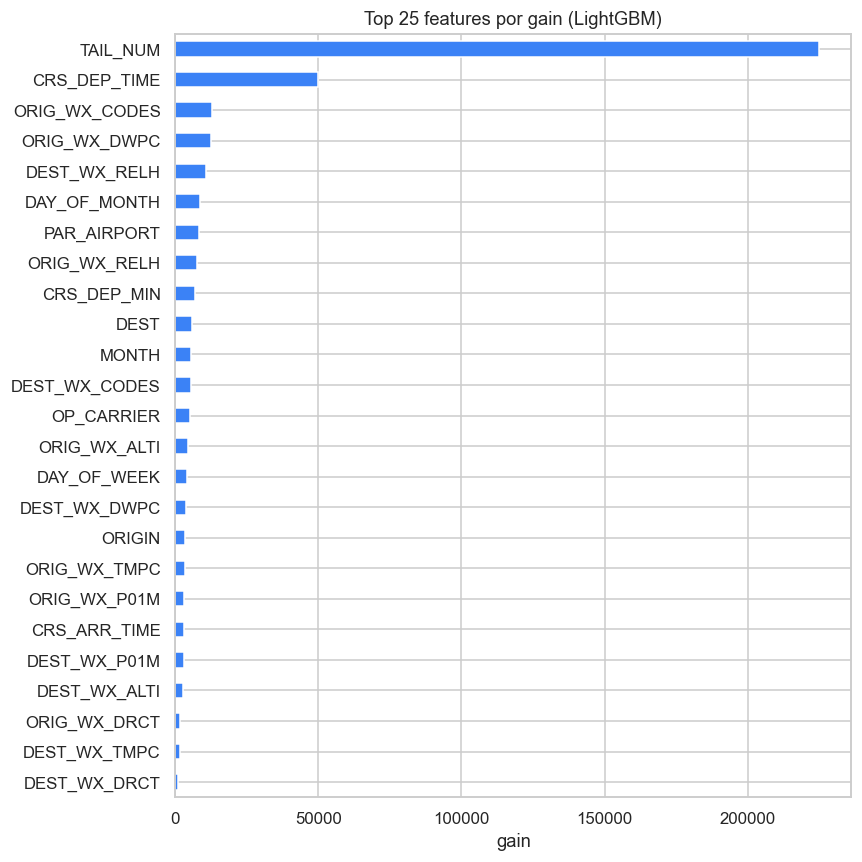

In [18]:
# (1) Gain importance
gain_imp = pd.Series(
    model_balanced.feature_importance(importance_type='gain'),
    index=X_train.columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
gain_imp.head(25).iloc[::-1].plot(kind='barh', ax=ax, color='#3b82f6')
ax.set_title('Top 25 features por gain (LightGBM)')
ax.set_xlabel('gain')
plt.tight_layout()
plt.show()


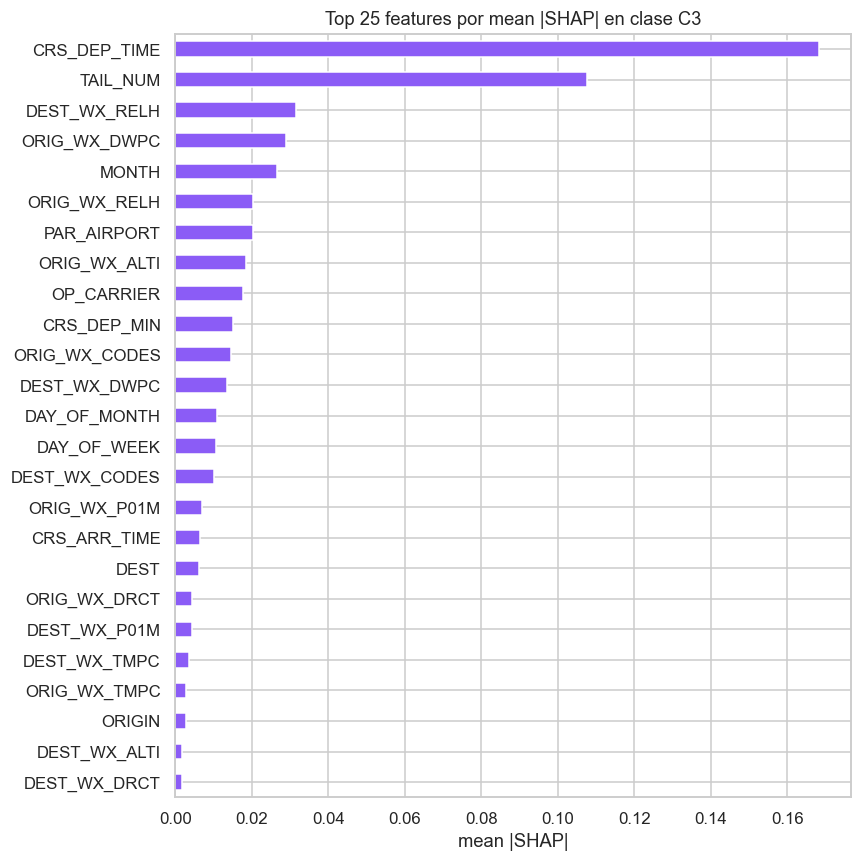

In [19]:
# (2) SHAP importance
import shap

# Muestra del val para no matar la RAM (shap es caro)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_val), size=min(3000, len(X_val)), replace=False)
X_shap = X_val.iloc[sample_idx]

explainer = shap.TreeExplainer(model_balanced)
shap_values = explainer.shap_values(X_shap)

# shap_values puede ser list(k arrays) [API vieja] o ndarray (n, k, c) [API nueva]
# Normalizar a (n_features,) con mean|SHAP| sobre clase C3
if isinstance(shap_values, list):
    # API vieja
    shap_c3_raw = np.abs(shap_values[CRITICAL_CLASS]).mean(axis=0)
else:
    arr = np.asarray(shap_values)
    # Shape posible: (n_samples, n_features, n_classes) o (n_samples, n_features)
    if arr.ndim == 3:
        shap_c3_raw = np.abs(arr[:, :, CRITICAL_CLASS]).mean(axis=0)
    else:
        shap_c3_raw = np.abs(arr).mean(axis=0)

shap_imp = pd.Series(shap_c3_raw, index=X_shap.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
shap_imp.head(25).iloc[::-1].plot(kind='barh', ax=ax, color='#8b5cf6')
ax.set_title('Top 25 features por mean |SHAP| en clase C3')
ax.set_xlabel('mean |SHAP|')
plt.tight_layout()
plt.show()


F1_C3 baseline en val: 0.220


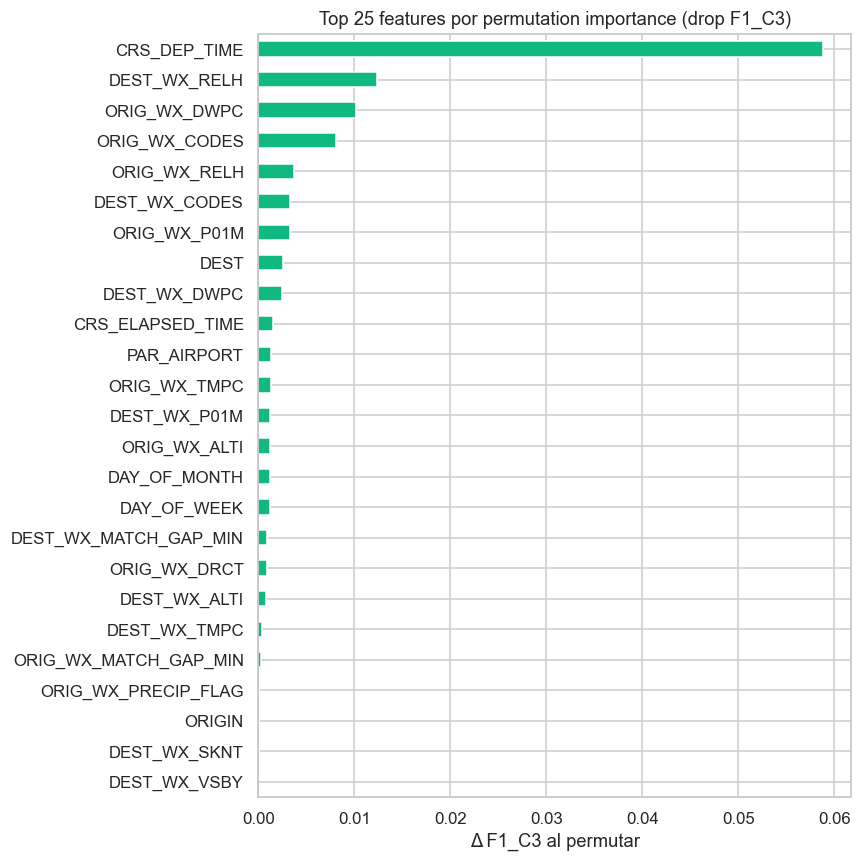

In [20]:
# (3) Permutation importance (caro — sobre muestra del val)
# Mide drop en F1_C3 al permutar cada feature

def score_f1_c3(model, X, y):
    proba = model.predict(X, num_iteration=model.best_iteration)
    pred = np.where(proba[:, 3] >= BEST_TH_C3, 3, proba.argmax(axis=1))
    return f1_score(y, pred, average=None, labels=[0,1,2,3], zero_division=0)[3]

baseline_f1 = score_f1_c3(model_balanced, X_val, y_val)
print(f'F1_C3 baseline en val: {baseline_f1:.3f}')

perm_results = {}
rng = np.random.RandomState(RANDOM_STATE)
n = len(X_val)
for col in X_val.columns:
    X_perm = X_val.copy()
    perm_idx = rng.permutation(n)
    # Permutamos por índice para preservar dtype (importante para categoricals)
    X_perm[col] = X_val[col].iloc[perm_idx].values
    if str(X_val[col].dtype) == 'category':
        X_perm[col] = X_perm[col].astype(pd.CategoricalDtype(categories=X_val[col].cat.categories))
    drop = baseline_f1 - score_f1_c3(model_balanced, X_perm, y_val)
    perm_results[col] = drop

perm_imp = pd.Series(perm_results).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
perm_imp.head(25).iloc[::-1].plot(kind='barh', ax=ax, color='#10b981')
ax.set_title('Top 25 features por permutation importance (drop F1_C3)')
ax.set_xlabel('Δ F1_C3 al permutar')
ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()


In [21]:
# Consolidación — ranking por las tres métricas
def rank_desc(s):
    return s.rank(ascending=False, method='min')

rank_df = pd.DataFrame({
    'gain_rank': rank_desc(gain_imp),
    'shap_rank': rank_desc(shap_imp),
    'perm_rank': rank_desc(perm_imp),
})
# Alineo columnas (puede haber missing si alguna no estaba en shap sample)
rank_df = rank_df.dropna()
rank_df['avg_rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')

n_feats = len(rank_df)
top_half = n_feats // 2

# Conteo de cuántas veces cada feature está en top 50%
in_top = (rank_df[['gain_rank', 'shap_rank', 'perm_rank']] <= top_half).sum(axis=1)
rank_df['in_top_half'] = in_top

# Features que quedan (en top 50% por al menos 2 métodos)
keep_features = rank_df[rank_df['in_top_half'] >= 2].index.tolist()
drop_features = rank_df[rank_df['in_top_half'] < 2].index.tolist()

print(f'Features recomendadas para MANTENER: {len(keep_features)}')
print(f'Features recomendadas para PODAR: {len(drop_features)}')
print(f'\nRanking consolidado (top 20):')
rank_df.head(20).round(1)


Features recomendadas para MANTENER: 22
Features recomendadas para PODAR: 20

Ranking consolidado (top 20):


,gain_rank,shap_rank,perm_rank,avg_rank,in_top_half
CRS_DEP_TIME,2.0,1.0,1.0,1.3,3
DEST_WX_RELH,5.0,3.0,2.0,3.3,3
ORIG_WX_DWPC,4.0,4.0,3.0,3.7,3
ORIG_WX_CODES,3.0,11.0,4.0,6.0,3
ORIG_WX_RELH,8.0,6.0,5.0,6.3,3
PAR_AIRPORT,7.0,7.0,11.0,8.3,3
DEST_WX_CODES,12.0,15.0,6.0,11.0,3
DAY_OF_MONTH,6.0,13.0,15.0,11.3,3
ORIG_WX_ALTI,14.0,8.0,14.0,12.0,3
DEST,10.0,18.0,8.0,12.0,3


In [22]:
# Lista explícita para Épica 2
print('━━━━━━━ FEATURE SET SUGERIDO (mantener) ━━━━━━━')
for f in keep_features:
    print(f'  ✓ {f}')
print(f'\n━━━━━━━ FEATURES A PODAR (ruido o redundantes) ━━━━━━━')
for f in drop_features:
    print(f'  ✗ {f}')


━━━━━━━ FEATURE SET SUGERIDO (mantener) ━━━━━━━
  ✓ CRS_DEP_TIME
  ✓ DEST_WX_RELH
  ✓ ORIG_WX_DWPC
  ✓ ORIG_WX_CODES
  ✓ ORIG_WX_RELH
  ✓ PAR_AIRPORT
  ✓ DEST_WX_CODES
  ✓ DAY_OF_MONTH
  ✓ ORIG_WX_ALTI
  ✓ DEST
  ✓ DEST_WX_DWPC
  ✓ MONTH
  ✓ ORIG_WX_P01M
  ✓ DAY_OF_WEEK
  ✓ TAIL_NUM
  ✓ ORIG_WX_TMPC
  ✓ DEST_WX_P01M
  ✓ CRS_DEP_MIN
  ✓ OP_CARRIER
  ✓ ORIG_WX_DRCT
  ✓ DEST_WX_TMPC
  ✓ CRS_ARR_TIME

━━━━━━━ FEATURES A PODAR (ruido o redundantes) ━━━━━━━
  ✗ CRS_ELAPSED_TIME
  ✗ ORIGIN
  ✗ DEST_WX_ALTI
  ✗ DEST_WX_MATCH_GAP_MIN
  ✗ DEST_WX_SKNT
  ✗ ORIG_WX_PRECIP_FLAG
  ✗ ORIG_WX_MATCH_GAP_MIN
  ✗ DEST_WX_DRCT
  ✗ ORIG_WX_VSBY
  ✗ DEST_WX_VSBY
  ✗ ORIG_WX_GUST
  ✗ ORIG_WX_SKNT
  ✗ DEST_WX_GUST
  ✗ DEST_WX_LOW_VIS_FLAG
  ✗ ORIG_WX_LOW_VIS_FLAG
  ✗ DEST_WX_PRECIP_FLAG
  ✗ DEST_WX_STRONG_WIND_FLAG
  ✗ FLOW_ATL
  ✗ ORIG_WX_STRONG_WIND_FLAG
  ✗ DISTANCE


## 12 · Conclusiones y roadmap

### Resumen de resultados

Compará los 3 modelos corridos:

| Modelo | Accuracy | F1_C3 | Recall_C3 | Precision_C3 |
|---|---|---|---|---|
| Baseline naive | ver output | ver output | ver output | ver output |
| Balanced (class_weight) | ver output | ver output | ver output | ver output |
| Balanced + threshold tuning | ver output | ver output | ver output | ver output |

### Traducción de negocio

- **Recall_C3 < 20%:** despacho ignora el sistema. No producible.
- **Recall_C3 30-50% con Precision_C3 ≥ 35%:** sistema utilizable con filtros adicionales. MVP mínimo.
- **Recall_C3 ≥ 50% con Precision_C3 ≥ 40%:** sistema que despacho usa en producción sin suplementos. Gate Épica 1.

### Next steps inmediatos

- [ ] **Épica 2 · ejecutar poda** con el `keep_features` de arriba → re-train + validar que F1_C3 no baja más de 5%.
- [ ] **Épica 3 · construir feature de cascada** — secuencia de últimas 3-5 rotaciones del mismo `TAIL_NUM` (temporal, cuidando no leakear).
- [ ] **Audit manual de `FLOW_ATL` y `PAR_AIRPORT`:** entender cuándo se computan en el ETL de tu compañero. Si son post-hoc, remover.
- [ ] **SHAP global plot** (summary_plot) para incluir en la presentación — es el insumo de explicabilidad que pide la cátedra.
- [ ] Guardar modelo final: `model_balanced.save_model('models/baseline_epic1_balanced.txt')`.

### Criterio de éxito de Épica 1

✅ **F1_C3 ≥ 0.45** en test con threshold tuned → ship a Épica 2.
✅ Leakage auditado: no hay features post-hoc en el modelo.
✅ Split temporal respetado (métricas no están infladas por leakage temporal).
